In [2]:
import pandas as pd
income = pd.read_csv('income.csv')
income.head()

,Age,Education,Salary
0,25,Bachelors,43.9
1,30,Bachelors,54.4
2,45,Bachelors,62.5
3,55,Bachelors,72.5
4,65,Bachelors,74.6


In [3]:
income.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Age        30 non-null     int64  
 1   Education  30 non-null     object 
 2   Salary     30 non-null     float64
dtypes: float64(1), int64(1), object(1)
memory usage: 852.0+ bytes


In [4]:
income.describe()

,Age,Salary
count,30.000000,30.000000
mean,43.366667,64.406667
std,14.375466,26.202684
min,24.000000,16.800000
25%,30.500000,46.350000
50%,45.000000,62.100000
75%,55.000000,76.800000
max,65.000000,118.000000


In [5]:
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

<Axes: xlabel='Education', ylabel='Salary'>

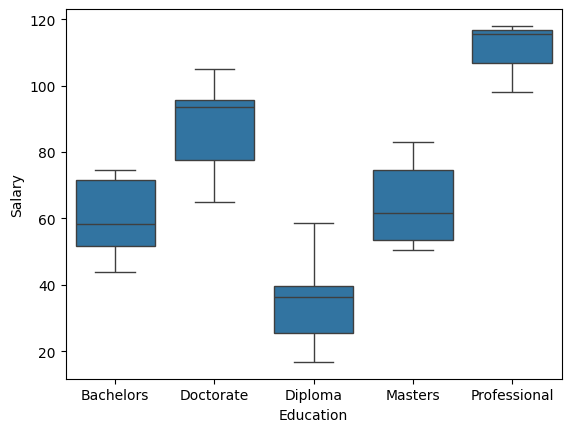

In [6]:
ax = sns.boxplot(data=income, x='Education', y='Salary')
ax

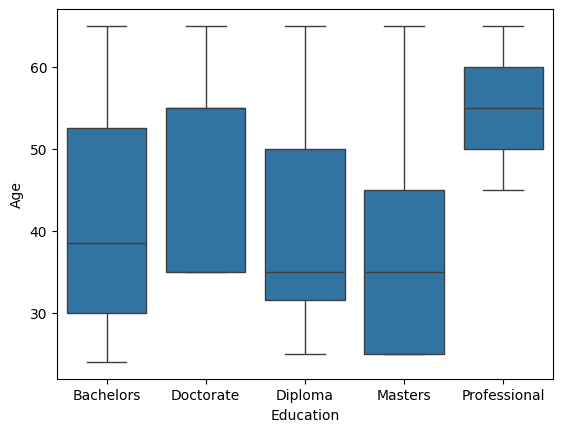

In [7]:
ax = sns.boxplot(data=income, x='Education', y='Age')

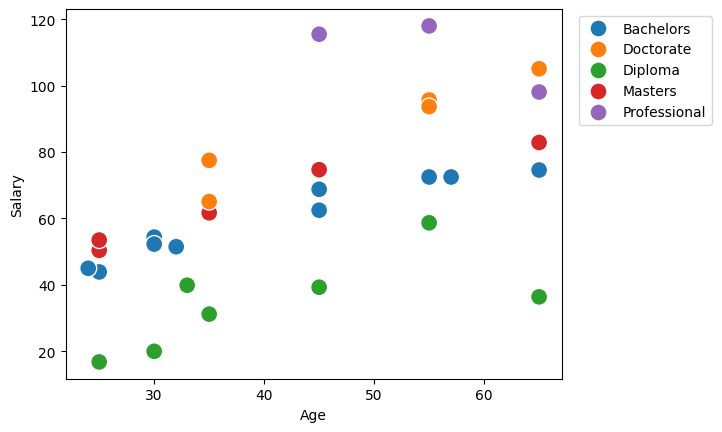

In [8]:
ax = sns.scatterplot(
    data = income,
    x='Age',
    y='Salary',
    hue = 'Education',
    s=150
)
ax = plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

In [9]:
y = income[['Salary']]

In [10]:
x = income[['Age', 'Education']]

In [18]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.6, stratify = x['Education'],random_state=1234)

In [20]:
x_train.shape, x_test.shape

((18, 2), (12, 2))

In [25]:
x_train.head()

,Age,Education
0,25,Bachelors
16,45,Masters
17,65,Masters
29,65,Professional
8,25,Diploma


In [35]:
x_train = pd.get_dummies(x_train)
x_train = x_train.astype(int)
x_train.head()

,Age,Education_Bachelors,Education_Diploma,Education_Doctorate,Education_Masters,Education_Professional
0,25,1,0,0,0,0
16,45,0,0,0,1,0
17,65,0,0,0,1,0
29,65,0,0,0,0,1
8,25,0,1,0,0,0


In [37]:
x_test = pd.get_dummies(x_test)
x_test = x_test.astype(int)
x_test.head()

,Age,Education_Bachelors,Education_Diploma,Education_Doctorate,Education_Masters,Education_Professional
9,30,0,1,0,0,0
21,25,0,0,0,1,0
4,65,1,0,0,0,0
10,35,0,1,0,0,0
7,65,0,0,1,0,0


In [41]:
from sklearn.tree import DecisionTreeRegressor
regressor = DecisionTreeRegressor(random_state=1234)

In [43]:
model = regressor.fit(x_train, y_train)

In [47]:
model.score(x_test, y_test)

0.5853149222529794

In [49]:
y_pred = model.predict(x_test)

In [51]:
from sklearn.metrics import mean_absolute_error
ms = mean_absolute_error(y_test, y_pred)
ms

13.541666666666666